## **COVID-19 Chest X-Ray Classification** 

### **Import Libraries** 

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
import random
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from torchvision import models
from torchvision.models import DenseNet121_Weights, resnet50, ResNet50_Weights, vgg16, VGG16_Weights
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize
import gradio as gr
import cv2
from PIL import Image

### **Device Setup**  

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device Using: cuda
GPU: Tesla T4


### **Dataset Path**  

In [3]:
Dataset_Path="/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"
classes=[d for d in os.listdir(Dataset_Path) if os.path.isdir(os.path.join(Dataset_Path, d))]
print("All Classes: ", classes)

All Classes:  ['Normal', 'Viral Pneumonia', 'COVID']


### **Image Transformation**  

In [4]:
Image_Size=224

train_transform= transforms.Compose([
    transforms.Resize((Image_Size, Image_Size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_test_transform= transforms.Compose([
    transforms.Resize((Image_Size, Image_Size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

### **Loading Dataset**  

In [5]:
full_dataset= datasets.ImageFolder(Dataset_Path, transform=train_transform)
class_names= full_dataset.classes
num_classes= len(class_names)

print("Classes Available:", class_names)
print("Total Images are:", len(full_dataset))

Classes Available: ['COVID', 'Normal', 'Viral Pneumonia']
Total Images are: 15153


### **Training/Validation/Test Data Split**  

In [6]:
train_size= int(0.7 * len(full_dataset))
val_size= int(0.15 * len(full_dataset))
test_size= len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds= random_split(full_dataset,[train_size,val_size,test_size])

train_ds.dataset.transform= train_transform
val_ds.dataset.transform= val_test_transform
test_ds.dataset.transform= val_test_transform
print("Training data:", len(train_ds),"\nValidation data:",len(val_ds),"\nTest data:",len(test_ds))

Training data: 10607 
Validation data: 2272 
Test data: 2274


### **DataLoaders**  

In [9]:
Batch_Size=32
train_loader= DataLoader(train_ds, batch_size=Batch_Size, shuffle=True)
val_loader= DataLoader(val_ds, batch_size=Batch_Size, shuffle=False)
test_loader= DataLoader(test_ds, batch_size=Batch_Size, shuffle=False)

### **Custom CNN Architecture**  

In [99]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.features=nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.MaxPool2d(2),
        )

        self.classifier= nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 28 * 28, 64),
            nn.ReLU(),
            nn.Dropout(0.85),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x= self.features(x)
        x= self.classifier(x)
        return x

### **Training Function**  

In [80]:
def train_model(model, name, epochs=20, patience=5):
    model.to(device)
    criterion= nn.CrossEntropyLoss()
    optimizer= optim.Adam(model.parameters(), lr=0.0001)

    history= {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": []
    }

    best_val_acc=0
    no_improve_counter=0

    for epoch in range(epochs):
        print(f"\n{name} -- Epoch {epoch+1}/{epochs}")

        model.train()
        correct, total, train_loss = 0, 0, 0

        for x, y in train_loader:
            x, y= x.to(device), y.to(device)
            optimizer.zero_grad()
            out= model(x)
            loss= criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_acc = correct / total
        train_loss /= len(train_loader)

        model.eval()
        correct, total, val_loss= 0, 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y= x.to(device), y.to(device)
                out= model(x)
                loss= criterion(out, y)

                val_loss += loss.item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_acc = correct / total
        val_loss /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Training Accuracy: {train_acc:.4f} -- Validation Accuracy: {val_acc:.4f}")
        print(f"Training Loss: {train_loss:.4f} -- Validation Loss: {val_loss:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve_counter = 0
            torch.save(model.state_dict(), f"/kaggle/working/{name}_best_weights.pth")
            print("Best Model Saved")
        else:
            no_improve_counter += 1
            print(f"No improvement for {no_improve_counter} epoch's")

        if no_improve_counter >= patience:
            print(f"Early stopping triggered after {patience} epochs with no improvement.")
            break

    return history

### **Training Custom CNN**  

In [100]:
custom_model = CustomCNN(num_classes)
custom_history = train_model(custom_model, "CustomCNN Model")


CustomCNN Model -- Epoch 1/20
Training Accuracy: 0.6254 -- Validation Accuracy: 0.7328
Training Loss: 0.7629 -- Validation Loss: 0.5487
Best Model Saved

CustomCNN Model -- Epoch 2/20
Training Accuracy: 0.6703 -- Validation Accuracy: 0.7914
Training Loss: 0.6640 -- Validation Loss: 0.5236
Best Model Saved

CustomCNN Model -- Epoch 3/20
Training Accuracy: 0.6903 -- Validation Accuracy: 0.7843
Training Loss: 0.6244 -- Validation Loss: 0.4834
No improvement for 1 epoch's

CustomCNN Model -- Epoch 4/20
Training Accuracy: 0.7059 -- Validation Accuracy: 0.7892
Training Loss: 0.6040 -- Validation Loss: 0.4628
No improvement for 2 epoch's

CustomCNN Model -- Epoch 5/20
Training Accuracy: 0.7057 -- Validation Accuracy: 0.7738
Training Loss: 0.5894 -- Validation Loss: 0.4574
No improvement for 3 epoch's

CustomCNN Model -- Epoch 6/20
Training Accuracy: 0.7108 -- Validation Accuracy: 0.8002
Training Loss: 0.5779 -- Validation Loss: 0.4412
Best Model Saved

CustomCNN Model -- Epoch 7/20
Training 

### **DenseNet121**  

In [95]:
densenet = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

for param in densenet.features.parameters():
    param.requires_grad = False

densenet.classifier = nn.Linear(densenet.classifier.in_features, num_classes)

dense_history = train_model(densenet, "DenseNet121 Model")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 182MB/s]



DenseNet121 Model -- Epoch 1/20
Training Accuracy: 0.6996 -- Validation Accuracy: 0.7628
Training Loss: 0.6817 -- Validation Loss: 0.5560
Best Model Saved

DenseNet121 Model -- Epoch 2/20
Training Accuracy: 0.8042 -- Validation Accuracy: 0.8121
Training Loss: 0.5010 -- Validation Loss: 0.4524
Best Model Saved

DenseNet121 Model -- Epoch 3/20
Training Accuracy: 0.8446 -- Validation Accuracy: 0.8482
Training Loss: 0.4258 -- Validation Loss: 0.3978
Best Model Saved

DenseNet121 Model -- Epoch 4/20
Training Accuracy: 0.8657 -- Validation Accuracy: 0.8684
Training Loss: 0.3812 -- Validation Loss: 0.3681
Best Model Saved

DenseNet121 Model -- Epoch 5/20
Training Accuracy: 0.8762 -- Validation Accuracy: 0.8715
Training Loss: 0.3557 -- Validation Loss: 0.3395
Best Model Saved

DenseNet121 Model -- Epoch 6/20
Training Accuracy: 0.8840 -- Validation Accuracy: 0.8790
Training Loss: 0.3332 -- Validation Loss: 0.3258
Best Model Saved

DenseNet121 Model -- Epoch 7/20
Training Accuracy: 0.8896 -- Va

### **ResNet50**  

In [96]:
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet_history = train_model(resnet, "ResNet50")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 239MB/s]



ResNet50 -- Epoch 1/20
Training Accuracy: 0.7062 -- Validation Accuracy: 0.7984
Training Loss: 0.6563 -- Validation Loss: 0.5188
Best Model Saved

ResNet50 -- Epoch 2/20
Training Accuracy: 0.8219 -- Validation Accuracy: 0.8209
Training Loss: 0.4612 -- Validation Loss: 0.4231
Best Model Saved

ResNet50 -- Epoch 3/20
Training Accuracy: 0.8560 -- Validation Accuracy: 0.8684
Training Loss: 0.3882 -- Validation Loss: 0.3731
Best Model Saved

ResNet50 -- Epoch 4/20
Training Accuracy: 0.8721 -- Validation Accuracy: 0.8759
Training Loss: 0.3501 -- Validation Loss: 0.3417
Best Model Saved

ResNet50 -- Epoch 5/20
Training Accuracy: 0.8812 -- Validation Accuracy: 0.8825
Training Loss: 0.3266 -- Validation Loss: 0.3225
Best Model Saved

ResNet50 -- Epoch 6/20
Training Accuracy: 0.8922 -- Validation Accuracy: 0.8944
Training Loss: 0.3055 -- Validation Loss: 0.3085
Best Model Saved

ResNet50 -- Epoch 7/20
Training Accuracy: 0.8952 -- Validation Accuracy: 0.8952
Training Loss: 0.2942 -- Validation L

### **VGG16**  

In [81]:
vgg= vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

for param in vgg.features.parameters():
    param.requires_grad = False

vgg.classifier = nn.Sequential(nn.Linear(vgg.classifier[0].in_features, 256),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(256, num_classes)
)

vgg_history = train_model(vgg, "VGG16 Model")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 206MB/s] 



VGG16 Model -- Epoch 1/20
Training Accuracy: 0.9288 -- Validation Accuracy: 0.9617
Training Loss: 0.1914 -- Validation Loss: 0.1034
Best Model Saved

VGG16 Model -- Epoch 2/20
Training Accuracy: 0.9788 -- Validation Accuracy: 0.9555
Training Loss: 0.0661 -- Validation Loss: 0.1089
No improvement for 1 epoch's

VGG16 Model -- Epoch 3/20
Training Accuracy: 0.9877 -- Validation Accuracy: 0.9762
Training Loss: 0.0406 -- Validation Loss: 0.0695
Best Model Saved

VGG16 Model -- Epoch 4/20
Training Accuracy: 0.9922 -- Validation Accuracy: 0.9771
Training Loss: 0.0251 -- Validation Loss: 0.0663
Best Model Saved

VGG16 Model -- Epoch 5/20
Training Accuracy: 0.9959 -- Validation Accuracy: 0.9815
Training Loss: 0.0143 -- Validation Loss: 0.0582
Best Model Saved

VGG16 Model -- Epoch 6/20
Training Accuracy: 0.9978 -- Validation Accuracy: 0.9767
Training Loss: 0.0105 -- Validation Loss: 0.0803
No improvement for 1 epoch's

VGG16 Model -- Epoch 7/20
Training Accuracy: 0.9981 -- Validation Accuracy:

### **Test Evaluation**  

In [102]:
def evaluate(model, path):
    model.load_state_dict(torch.load(path))
    model.to(device) 
    model.eval()

    y_true, y_pred = [],[]

    with torch.no_grad():
        for x, y in test_loader:
            x= x.to(device)
            out = model(x)
            preds = out.argmax(1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\n\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

### **Evaluating Models**  

Custom CNN Model Results
Confusion Matrix:


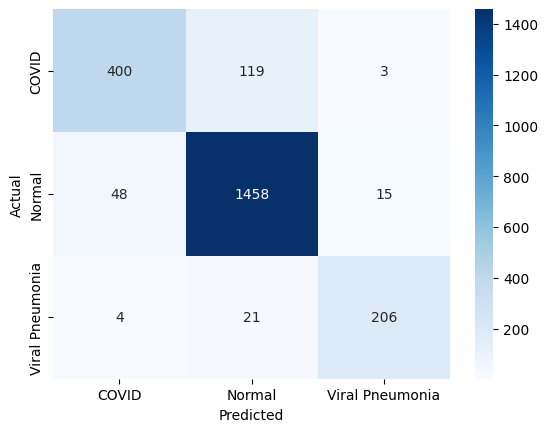



Classification Report:
                 precision    recall  f1-score   support

          COVID       0.88      0.77      0.82       522
         Normal       0.91      0.96      0.93      1521
Viral Pneumonia       0.92      0.89      0.91       231

       accuracy                           0.91      2274
      macro avg       0.91      0.87      0.89      2274
   weighted avg       0.91      0.91      0.91      2274



Densenet121 Results
Confusion Matrix:


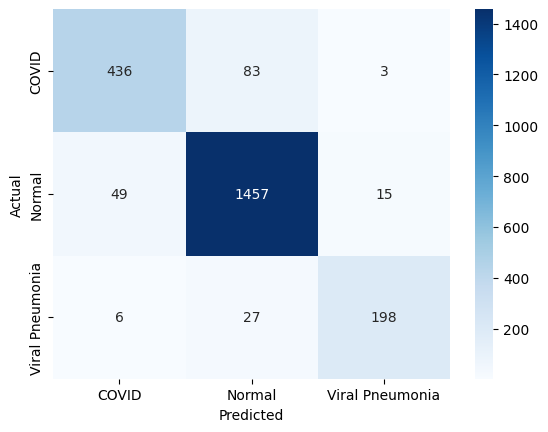



Classification Report:
                 precision    recall  f1-score   support

          COVID       0.89      0.84      0.86       522
         Normal       0.93      0.96      0.94      1521
Viral Pneumonia       0.92      0.86      0.89       231

       accuracy                           0.92      2274
      macro avg       0.91      0.88      0.90      2274
   weighted avg       0.92      0.92      0.92      2274



ResNet50 Results
Confusion Matrix:


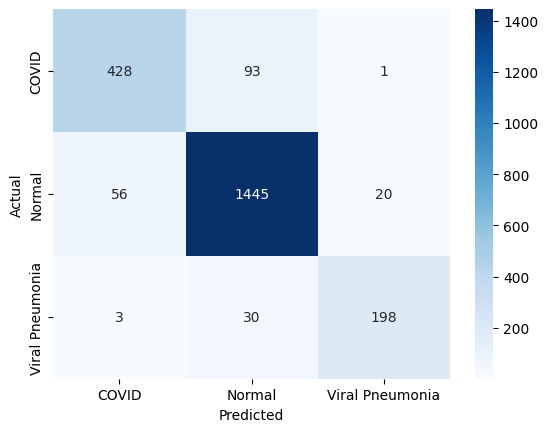



Classification Report:
                 precision    recall  f1-score   support

          COVID       0.88      0.82      0.85       522
         Normal       0.92      0.95      0.94      1521
Viral Pneumonia       0.90      0.86      0.88       231

       accuracy                           0.91      2274
      macro avg       0.90      0.88      0.89      2274
   weighted avg       0.91      0.91      0.91      2274



VGG16 Results
Confusion Matrix:


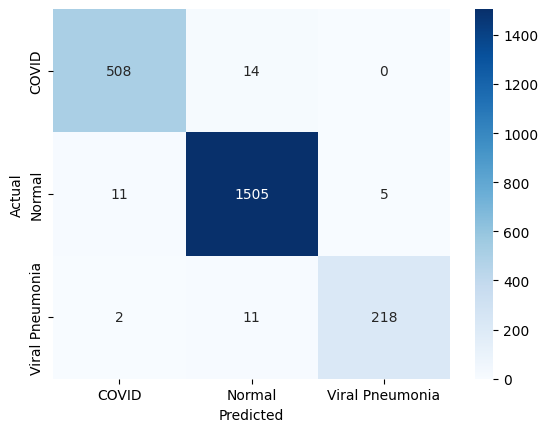



Classification Report:
                 precision    recall  f1-score   support

          COVID       0.98      0.97      0.97       522
         Normal       0.98      0.99      0.99      1521
Viral Pneumonia       0.98      0.94      0.96       231

       accuracy                           0.98      2274
      macro avg       0.98      0.97      0.97      2274
   weighted avg       0.98      0.98      0.98      2274



In [105]:
print("Custom CNN Model Results")
evaluate(custom_model, "/kaggle/working/CustomCNN Model_best_weights.pth")

print("\n\nDensenet121 Results")
evaluate(densenet, "/kaggle/working/DenseNet121 Model_best_weights.pth")

print("\n\nResNet50 Results")
evaluate(resnet, "/kaggle/working/ResNet50_best_weights.pth")

print("\n\nVGG16 Results")
evaluate(vgg, "/kaggle/working/VGG16 Model_best_weights.pth")

### **Plot Comparison Graph**  

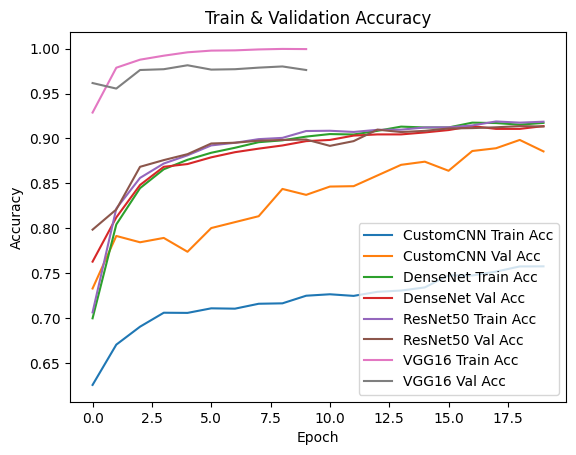

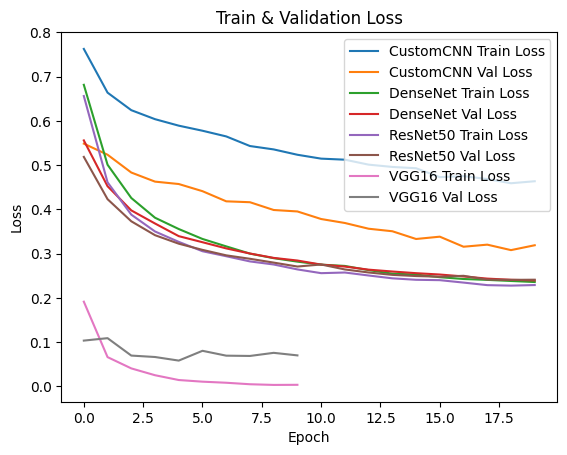

In [106]:
plt.plot(custom_history["train_acc"], label="CustomCNN Train Acc")
plt.plot(custom_history["val_acc"], label="CustomCNN Val Acc")
plt.plot(dense_history["train_acc"], label="DenseNet Train Acc")
plt.plot(dense_history["val_acc"], label="DenseNet Val Acc")
plt.plot(resnet_history["train_acc"], label="ResNet50 Train Acc")
plt.plot(resnet_history["val_acc"], label="ResNet50 Val Acc")
plt.plot(vgg_history["train_acc"], label="VGG16 Train Acc")
plt.plot(vgg_history["val_acc"], label="VGG16 Val Acc")
plt.title("Train & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(custom_history["train_loss"], label="CustomCNN Train Loss")
plt.plot(custom_history["val_loss"], label="CustomCNN Val Loss")
plt.plot(dense_history["train_loss"], label="DenseNet Train Loss")
plt.plot(dense_history["val_loss"], label="DenseNet Val Loss")
plt.plot(resnet_history["train_loss"], label="ResNet50 Train Loss")
plt.plot(resnet_history["val_loss"], label="ResNet50 Val Loss")
plt.plot(vgg_history["train_loss"], label="VGG16 Train Loss")
plt.plot(vgg_history["val_loss"], label="VGG16 Val Loss")
plt.title("Train & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### **Loading VGG16 Model**  

In [10]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes= 3

vgg= models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

vgg.classifier = nn.Sequential(nn.Linear(25088, 256),
                               nn.ReLU(),
                               nn.Dropout(0.5),
                               nn.Linear(256, num_classes)
)

vgg.to(device)
best_vgg_path= "/kaggle/input/vgg16model/other/default/1/VGG16 Model_best_weights.pth"
vgg.load_state_dict(torch.load(best_vgg_path, map_location=device))
vgg.eval()
print("VGG16 model loaded successfully")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 242MB/s]  


VGG16 model loaded successfully


### **Confidence Score**  

In [12]:
def confidence_predict(model, image_tensor):
    model.eval()
    image_tensor= image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        outputs= model(image_tensor)
        probs= F.softmax(outputs, dim=1)
        confidence, predicted_class= torch.max(probs,1)

    return class_names[predicted_class.item()], confidence.item()

### **Test on Random Images**   

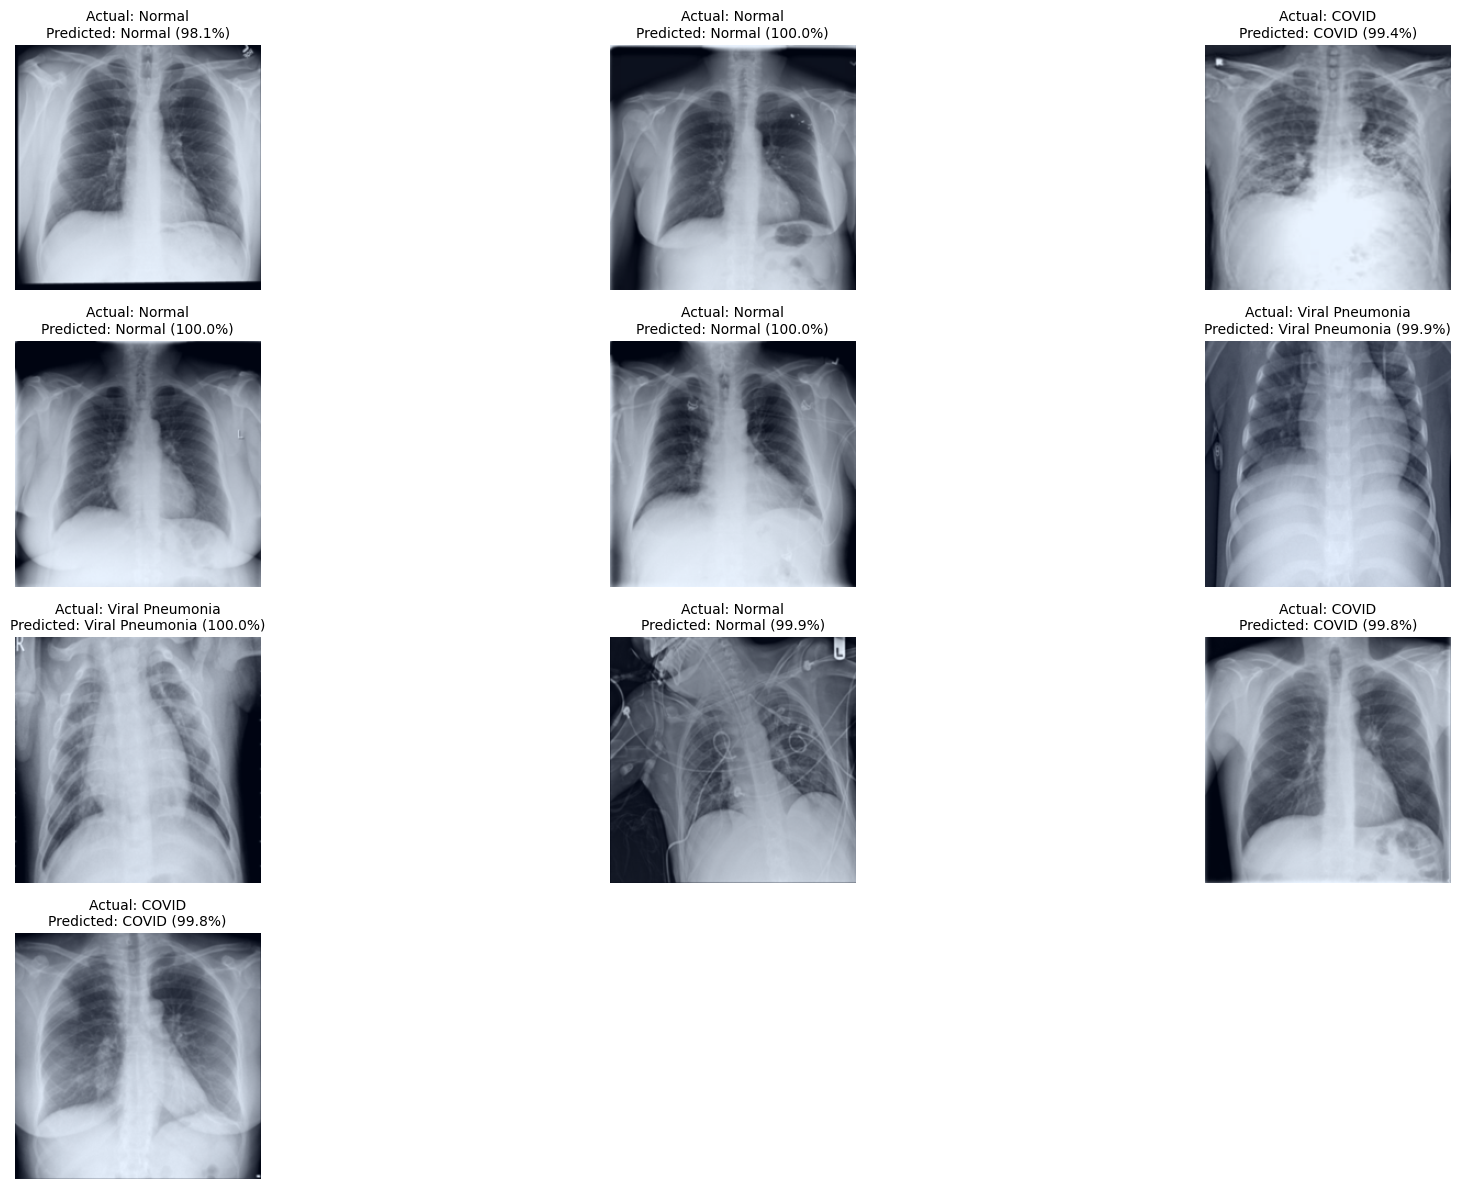

In [13]:
vgg.eval()
random_indices= random.sample(range(len(test_ds)), 10)
plt.figure(figsize=(18, 12))

def confidence_predict(model, image_tensor):
    model.eval()
    image_tensor= image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        outputs= model(image_tensor)
        probs= F.softmax(outputs, dim=1)
        confidence, predicted_class= torch.max(probs, 1)

    return class_names[predicted_class.item()], confidence.item()


for i, idx in enumerate(random_indices):
    img, label= test_ds[idx]

    pred_class, conf= confidence_predict(vgg, img)

    img_np= img.permute(1, 2, 0).cpu().numpy()
    img_np= (img_np - img_np.min()) / (img_np.max() - img_np.min())

    plt.subplot(4, 3, i + 1)
    plt.imshow(img_np)
    plt.title(f"Actual: {class_names[label]}\nPredicted: {pred_class} ({conf*100:.1f}%)", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

### **ROC-AUC Getting Ground Truth & Probabilities**  

In [113]:
y_true= []
y_probs= []

with torch.no_grad():
    for x, y in test_loader:
        x= x.to(device)
        outputs= vgg(x)
        probs= F.softmax(outputs, dim=1).cpu().numpy()

        y_probs.extend(probs)
        y_true.extend(y.numpy())

y_true= np.array(y_true)
y_probs= np.array(y_probs)

y_true_bin= label_binarize(y_true, classes=range(num_classes))

### **ROC-AUC Curve Visualization**  

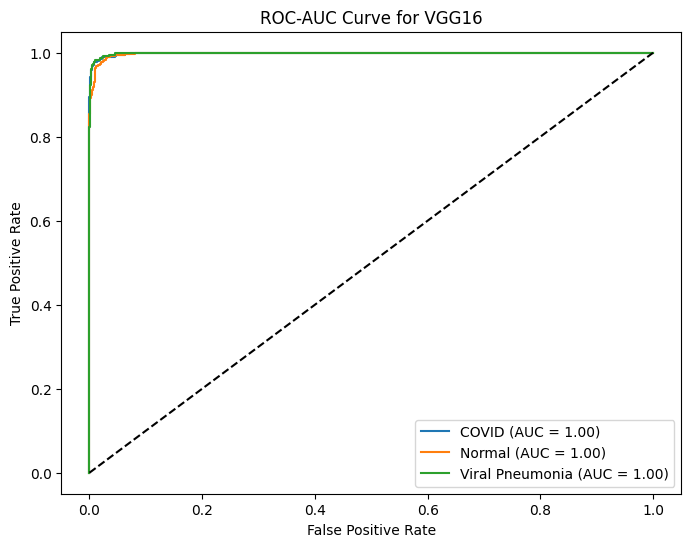

In [114]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _= roc_curve(y_true_bin[:, i], y_probs[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve for VGG16")
plt.legend()
plt.show()

### **Grad-CAM Class for VGG16**  

In [15]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model= model
        self.target_layer= target_layer
        self.activations= None
        self.gradients= None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients= grad_output[0]
        
    def generate(self, input_tensor, class_idx, input_size=(224,224)):
        self.model.eval()
        input_tensor= input_tensor.clone().detach()
        input_tensor.requires_grad= True

        output= self.model(input_tensor)
        self.model.zero_grad()
        output[:, class_idx].backward()

        weights= self.gradients.mean(dim=[2,3], keepdim=True)
        cam= (weights * self.activations).sum(dim=1, keepdim=True)
        cam= F.relu(cam)

        cam= cam - cam.min()
        cam= cam / (cam.max() + 1e-8)
        cam= F.interpolate(cam, size=input_size, mode='bilinear', align_corners=False)
        return cam.detach()

### **Grad_CAM Visualization**  

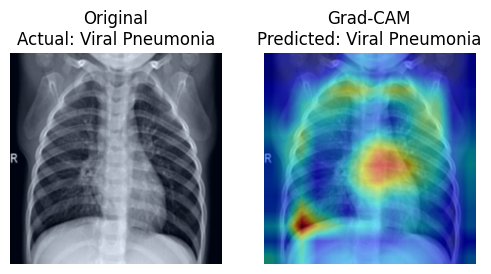

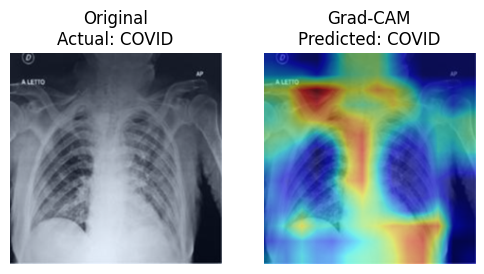

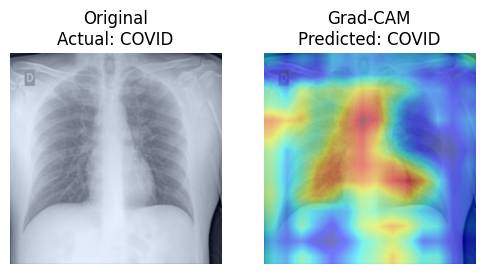

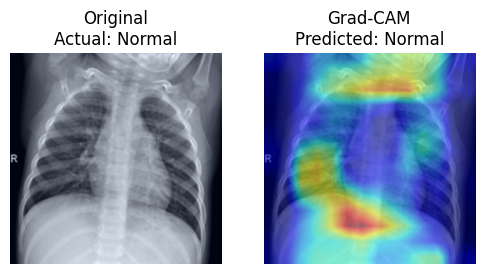

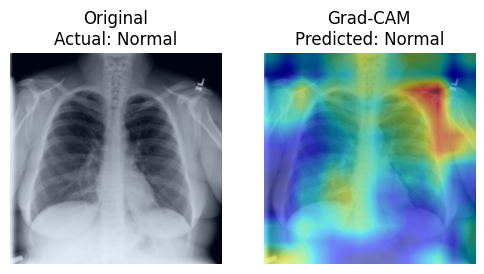

In [124]:
target_layer= vgg.features[28]
gradcam= GradCAM(vgg, target_layer)

random_indices= random.sample(range(len(test_ds)), 5)

for i, idx in enumerate(random_indices):
    img_tensor, label= test_ds[idx]
    input_tensor= img_tensor.unsqueeze(0).to(device)

    vgg.eval()
    output= vgg(input_tensor)
    pred_class= output.argmax(1).item()

    cam= gradcam.generate(input_tensor, pred_class, input_size=(img_tensor.shape[1], img_tensor.shape[2]))
    cam= cam.squeeze().cpu().numpy()

    img_np= img_tensor.permute(1,2,0).numpy()
    img_np= (img_np - img_np.min()) / (img_np.max() - img_np.min())

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"Original\nActual: {class_names[label]}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img_np)
    plt.imshow(cam, cmap="jet", alpha=0.5)
    plt.title(f"Grad-CAM\nPredicted: {class_names[pred_class]}")
    plt.axis("off")
    plt.show()

### **Comparison Table**  

In [134]:
results = {
    "Model": ["CustomCNN", "DenseNet121", "ResNet50", "VGG16"],
    "Best Val Accuracy": [
        max(custom_history["val_acc"]),
        max(dense_history["val_acc"]),
        max(resnet_history["val_acc"]),
        max(vgg_history["val_acc"])
    ],
    "Best Train Accuracy": [
        max(custom_history["train_acc"]),
        max(dense_history["train_acc"]),
        max(resnet_history["train_acc"]),
        max(vgg_history["train_acc"])
    ],
    "Train Loss": [
        custom_history["train_loss"][custom_history["val_acc"].index(max(custom_history["val_acc"]))],
        dense_history["train_loss"][dense_history["val_acc"].index(max(dense_history["val_acc"]))],
        resnet_history["train_loss"][resnet_history["val_acc"].index(max(resnet_history["val_acc"]))],
        vgg_history["train_loss"][vgg_history["val_acc"].index(max(vgg_history["val_acc"]))]
    ],
    "Val Loss": [
        custom_history["val_loss"][custom_history["val_acc"].index(max(custom_history["val_acc"]))],
        dense_history["val_loss"][dense_history["val_acc"].index(max(dense_history["val_acc"]))],
        resnet_history["val_loss"][resnet_history["val_acc"].index(max(resnet_history["val_acc"]))],
        vgg_history["val_loss"][vgg_history["val_acc"].index(max(vgg_history["val_acc"]))]
    ]
}

results_df = pd.DataFrame(results)
display(results_df)

,Model,Best Val Accuracy,Best Train Accuracy,Train Loss,Val Loss
0,CustomCNN,0.898327,0.757519,0.459157,0.307981
1,DenseNet121,0.913732,0.917602,0.242676,0.248454
2,ResNet50,0.913732,0.918921,0.227705,0.240709
3,VGG16,0.981514,0.999717,0.014259,0.058196


### **Best Model Accuracy**  

In [135]:
best_idx= results_df["Best Val Accuracy"].idxmax()
best_model_name= results_df.loc[best_idx, "Model"]
print(f"Best Model Based on Validation Accuracy is: {best_model_name}\n")

Best Model Based on Validation Accuracy is: VGG16



### **Saving Result**  

In [136]:
results_df.to_csv("/kaggle/working/final_model_comparison.csv", index=False)
print("Results saved to final_model_comparison.csv successfully")

Results saved to final_model_comparison.csv successfully


### **Install Gradio**  

In [17]:
!pip install -q gradio

### **Loading VGG16 Model for Web**  

In [18]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes= len(class_names)

vgg_web= models.vgg16(weights=None)

vgg_web.classifier = nn.Sequential(nn.Linear(25088, 256),
                                   nn.ReLU(),
                                   nn.Dropout(0.5),
                                   nn.Linear(256, num_classes)
)

best_model_path = "/kaggle/input/vgg16model/other/default/1/VGG16 Model_best_weights.pth"
vgg_web.load_state_dict(torch.load(best_model_path, map_location=device))
vgg_web.to(device)
vgg_web.eval()
print("VGG16 model loaded for web interface")

VGG16 model loaded for web interface


### **Initializing Grad-CAM**  

In [47]:
target_layer= vgg_web.features[-1]
gradcam= GradCAM(vgg_web, target_layer)

### **Image Preprocessing**  

In [35]:
def preprocess_image(image):
    if image is None:
        return None

    image= image.convert("RGB")
    image= val_test_transform(image)
    image= image.unsqueeze(0).to(device)
    return image

### **Prediction Function**  

In [41]:
def predict_xray(image):
    input_tensor= preprocess_image(image)

    with torch.no_grad():
        outputs= vgg_web(input_tensor)
        probs= F.softmax(outputs, dim=1)
        confidence, predicted_class= torch.max(probs, 1)

    cam= gradcam.generate(
        input_tensor,
        predicted_class.item(),
        input_size=(224, 224)
    )

    cam= cam.squeeze().cpu().numpy()
    image_np = np.array(image.resize((224, 224)))
    image_np = image_np / 255.0

    jet= cm.get_cmap("jet")
    heatmap= jet(cam)[:, :, :3]

    gradcam_img= (0.5 * image_np + 0.5 * heatmap)
    gradcam_img= np.clip(gradcam_img, 0, 1)

    predicted_label= class_names[predicted_class.item()]
    confidence_score= confidence.item() * 100

    return predicted_label, f"{confidence_score:.2f}%", gradcam_img

### **Web Interface**  

In [79]:
with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="blue",
        neutral_hue="slate"
    ),
    css="body { background-color: white !important; }"
) as interface:

    gr.Markdown(
        """
        <h1 style='text-align: center; color: #0b5ed7; font-size: 50px; margin-top: 40px; margin-bottom: 40px;'>
        AI-Driven COVID-19 Chest X-Ray Classification
        </h1>

        <p style='text-align: center; font-size: 18px; color:white;'>
        This system uses a deep learning model (VGG16) to analyze chest X-ray images
        and classify them into COVID-19, Viral Pneumonia, or Normal cases.
        <br>
        The goal is to assist healthcare professionals by providing fast and
        explainable AI-based predictions.
        </p>
        """,
        elem_id="header"
    )

    gr.Markdown("---")
    gr.Markdown("---")

    with gr.Row():
        input_image = gr.Image(
            type="pil",
            label="Upload Chest X-Ray Image",
            height=400
        )

    gr.Markdown("---")
    gr.Markdown("---")
    predicted_label = gr.Label(label="Predicted Class")
    confidence_box = gr.Textbox(label="Confidence Score")
    gradcam_image = gr.Image(label="Grad-CAM Visualization")

    submit_btn = gr.Button("Analyze X-Ray Image", variant="primary")

    gr.Markdown(
        """
        <p style='color:white; text-align:center; margin-top:10px;'>
        <b>Disclaimer:</b> This AI system is not 100% accurate and is intended
        for educational and research purposes only.
        Always consult a qualified medical professional before making any clinical decisions.
        </p>
        """
    )

    submit_btn.click(
        fn=predict_xray,
        inputs=input_image,
        outputs=[predicted_label, confidence_box, gradcam_image]
    )

### **Launch Web App**  

In [ ]:
interface.launch(share=True, debug=False)